In [15]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [ ]:
# # Paths to dataset folders
# base_path = r"D:\ANN and DL"
# folders = ["Gesture_0", "Gesture_2", "Gesture_13"]

# # Load dataset
# X = []
# y = []

# for folder in folders:
#     label = int(folder.split("_")[1])
#     folder_path = os.path.join(base_path, folder)
    
#     # Check if the folder exists before listing files
#     if not os.path.exists(folder_path):
#         print(f"⚠️ Warning: Folder skipped (not found): {folder_path}")
#         continue

#     # Read images directly from the main folder path
#     for img_name in os.listdir(folder_path):
#         img_path = os.path.join(folder_path, img_name)
        
#         # Ensure it's a file, not a nested subdirectory
#         if os.path.isdir(img_path):
#             continue
            
#         img = cv2.imread(img_path)
#         if img is None:
#             continue
            
#         img = img.astype('float32') / 255.0  # normalize to 0–1
#         X.append(img.flatten())
#         y.append(label)

# X = np.array(X)
# y = np.array(y)

# print(f"✅ Dataset loaded: {X.shape[0]} samples, each of size {X.shape[1] if X.ndim > 1 else 0}")
base_path = r"D:\ANN and DL"
folders = ["Gesture_0", "Gesture_2", "Gesture_13"]
res = "110x110x3"

# Load dataset
X = []
y = []

for folder in folders:
    label = int(folder.split("_")[1])
    folder_path = os.path.join(base_path, folder, res)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = img.astype('float32') / 255.0  # normalize to 0–1
        X.append(img.flatten())  # flatten 110x110x3 -> 36300 features
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f" Dataset loaded: {X.shape[0]} samples, each of size {X.shape[1]}")

✅ Dataset loaded: 3000 samples, each of size 196608


In [ ]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# One-hot encode labels
num_classes = len(np.unique(y))
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
#1. Map labels (0, 2, 13) -> (0, 1, 2)
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)

# # 2. Split the dataset using your new encoded labels
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# # 3. One-hot encode labels safely
# num_classes = len(np.unique(y_encoded))
# y_train = tf.keras.utils.to_categorical(y_train, num_classes)
# y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [18]:
# Build ANN model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),        # Input layer
    tf.keras.layers.Dense(256, activation='relu'),     # Hidden layer
    tf.keras.layers.Dense(num_classes, activation='softmax')  # Output layer
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
# Train until convergence
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,           # You can increase this if loss doesn't converge
    batch_size=32,
    verbose=1
)

Epoch 1/50


75/75 [==============================] - 44s 530ms/step - loss: 20.9755 - accuracy: 0.3537 - val_loss: 3.4727 - val_accuracy: 0.3500
Epoch 2/50
75/75 [==============================] - 35s 473ms/step - loss: 4.6063 - accuracy: 0.3862 - val_loss: 3.0231 - val_accuracy: 0.4333
Epoch 3/50
75/75 [==============================] - 35s 470ms/step - loss: 2.7437 - accuracy: 0.4508 - val_loss: 2.4644 - val_accuracy: 0.3700
Epoch 4/50
75/75 [==============================] - 36s 482ms/step - loss: 6.7130 - accuracy: 0.4129 - val_loss: 2.3302 - val_accuracy: 0.5133
Epoch 5/50
75/75 [==============================] - 37s 495ms/step - loss: 2.7800 - accuracy: 0.4613 - val_loss: 2.1617 - val_accuracy: 0.5033
Epoch 6/50
75/75 [==============================] - 37s 488ms/step - loss: 1.7465 - accuracy: 0.5296 - val_loss: 1.1958 - val_accuracy: 0.5100
Epoch 7/50
75/75 [==============================] - 36s 482ms/step - loss: 3.7647 - accuracy: 0.4254 - val_loss: 2.6445 - val_accuracy: 0.4

19/19 [==============================] - 1s 76ms/step - loss: 0.9511 - accuracy: 0.4617

 Test Accuracy: 0.4617
 Test Loss: 0.9511


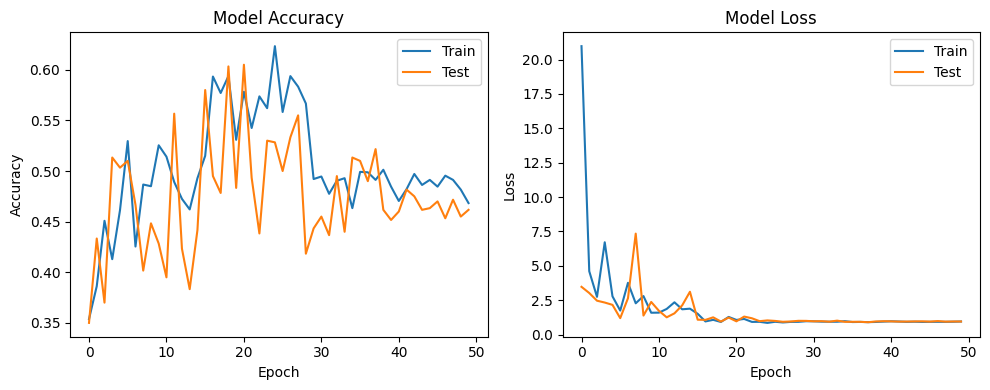

In [20]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")

# Plot Accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()